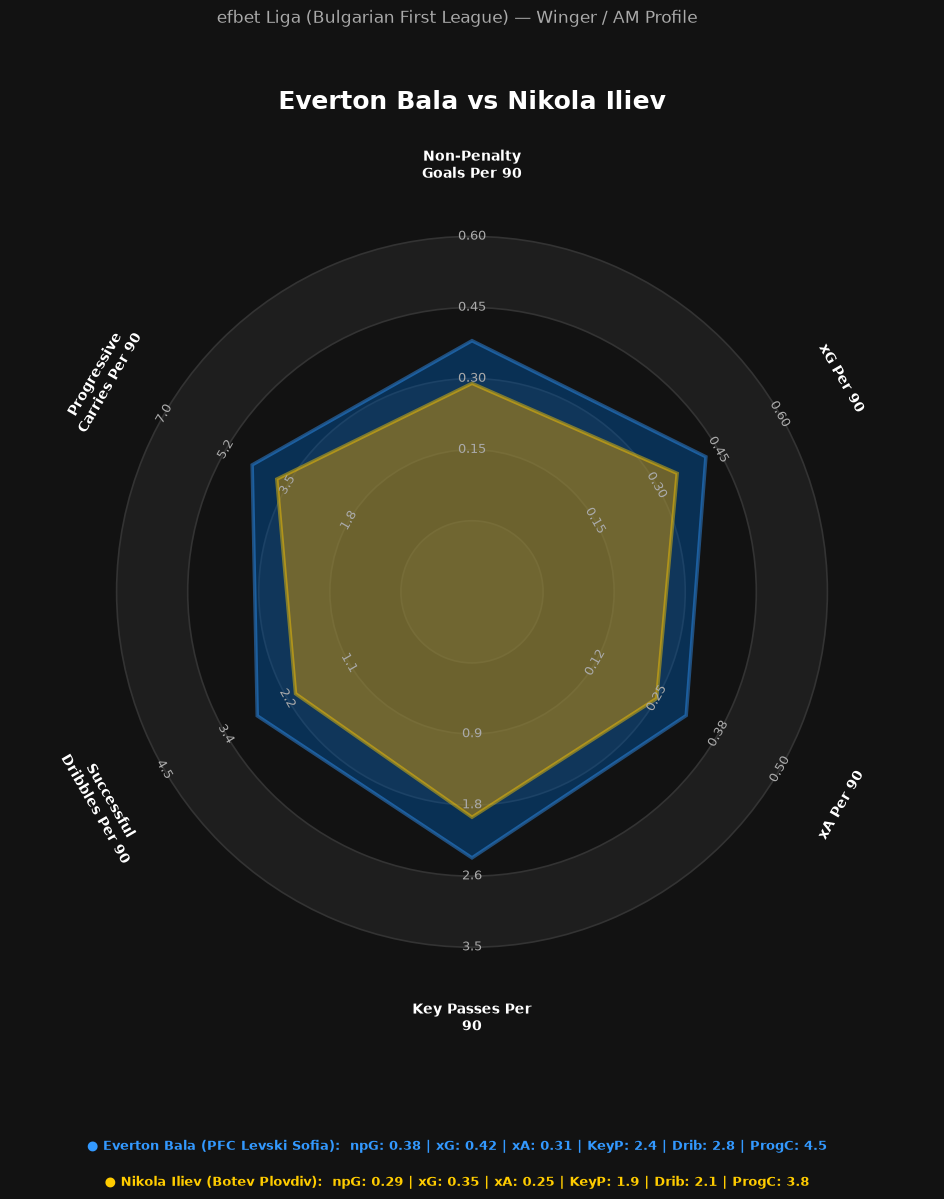

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Radar

# ============================================================
# 1. ДАННИ ЗА ИГРАЧИТЕ ОТ ПЪРВА ЛИГА (PER 90)
# ============================================================
# Данните могат да бъдат намерени/обновени от FBref или Sofascore
# За пример сравняваме двама офанзивни играчи от Първа лига:

player1_name = "Everton Bala"
player1_team = "PFC Levski Sofia"
# [npxG, xG, xA, Key Passes, Successful Dribbles, Progressive Carries]
player1_stats = [0.38, 0.42, 0.31, 2.40, 2.80, 4.50]

player2_name = "Nikola Iliev"
player2_team = "Botev Plovdiv"
player2_stats = [0.29, 0.35, 0.25, 1.90, 2.10, 3.80]


# ============================================================
# 2. МЕТРИКИ И ГРАНИЦИ ЗА ПЪРВА ЛИГА (SCALING)
# ============================================================
params = [
    "Non-Penalty Goals\nPer 90",
    "xG\nPer 90",
    "xA\nPer 90",
    "Key Passes\nPer 90",
    "Successful Dribbles\nPer 90",
    "Progressive Carries\nPer 90",
]

# Мин. и макс. стойности за офанзивни халфове/крила в Първа лига
low = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
high = [0.6, 0.6, 0.5, 3.5, 4.5, 7.0]

radar = Radar(
    params, low, high, lower_is_better=[], round_int=[False] * 6, num_rings=4
)


# ============================================================
# 3. ПОСТРОЯВАНЕ НА ГРАФИКАТА
# ============================================================
fig, ax = radar.setup_axis(facecolor="#121212")
fig.set_facecolor("#121212")

# Фонови окръжности и разделителни линии
radar.draw_circles(
    ax=ax, facecolor="#1e1e1e", edgecolor="#333333", linewidth=1.2
)

# ЧЕРТАЕНЕ НА СРАВНЕНИЕТО
radar.draw_radar_compare(
    player1_stats,
    player2_stats,
    ax=ax,
    kwargs_radar={
        "facecolor": "#0055a5",  # Синьо за Левски
        "alpha": 0.45,
        "edgecolor": "#3399ff",
        "linewidth": 2.5,
    },
    kwargs_compare={
        "facecolor": "#e6a100",  # Жълто/Златисто за Ботев Пд
        "alpha": 0.45,
        "edgecolor": "#ffcc00",
        "linewidth": 2.5,
    },
)

# Текстови етикети
radar.draw_range_labels(ax=ax, fontsize=9, color="#aaaaaa")
radar.draw_param_labels(ax=ax, fontsize=10, color="white", fontweight="bold")


# ============================================================
# 4. ЗАГЛАВИЯ И ЛЕГЕНДА
# ============================================================
plt.suptitle(
    "efbet Liga (Bulgarian First League) — Winger / AM Profile",
    color="#aaaaaa",
    fontsize=12,
    y=0.98,
)
plt.title(
    f"{player1_name} vs {player2_name}",
    color="white",
    fontsize=18,
    pad=15,
    fontweight="bold",
)

legend_p1 = (
    f"● {player1_name} ({player1_team}):  "
    f"npG: {player1_stats[0]} | xG: {player1_stats[1]} | xA: {player1_stats[2]} | "
    f"KeyP: {player1_stats[3]} | Drib: {player1_stats[4]} | ProgC: {player1_stats[5]}"
)

legend_p2 = (
    f"● {player2_name} ({player2_team}):  "
    f"npG: {player2_stats[0]} | xG: {player2_stats[1]} | xA: {player2_stats[2]} | "
    f"KeyP: {player2_stats[3]} | Drib: {player2_stats[4]} | ProgC: {player2_stats[5]}"
)

fig.text(
    0.5,
    0.03,
    legend_p1,
    color="#3399ff",
    fontsize=9.5,
    ha="center",
    fontweight="bold",
)
fig.text(
    0.5,
    0.00,
    legend_p2,
    color="#ffcc00",
    fontsize=9.5,
    ha="center",
    fontweight="bold",
)


# ============================================================
# 5. ЗАПАЗВАНЕ
# ============================================================
plt.savefig(
    "parva_liga_winger_radar.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#121212",
)
plt.show()